In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = "/content/drive/MyDrive/capstone/praprosesing/evaluasi_preprocessing.csv"

In [ ]:
df = pd.read_csv(file_path)

df.head()

,kelas,contrast,sharp,black_ratio,edge
0,total_harga_barang,0.123282,131.075619,0.208984,0.129639
1,nama_produk,0.170832,2947.541076,0.061035,0.150391
2,total_harga_barang,0.095363,91.435538,0.000488,0.084473
3,harga_satuan,0.122548,177.162044,0.145020,0.119873
4,nama_produk,0.122358,5702.474161,0.058594,0.198975


In [ ]:
print(df.columns)
df.info()
df.describe()

Index(['kelas', 'contrast', 'sharp', 'black_ratio', 'edge'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4531 entries, 0 to 4530
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   kelas        4531 non-null   object 
 1   contrast     4531 non-null   float64
 2   sharp        4531 non-null   float64
 3   black_ratio  4531 non-null   float64
 4   edge         4531 non-null   float64
dtypes: float64(4), object(1)
memory usage: 177.1+ KB


,contrast,sharp,black_ratio,edge
count,4531.000000,4531.000000,4531.000000,4531.000000
mean,0.137735,977.657082,0.059817,0.111594
std,0.046046,2299.037108,0.095725,0.051654
min,0.000921,0.063476,0.000000,0.000000
25%,0.106836,66.253892,0.004150,0.079590
50%,0.133102,176.875725,0.028809,0.107422
75%,0.163863,574.382703,0.088135,0.147217
max,0.329778,21424.784240,1.000000,0.308838


In [ ]:
# hapus spasi & rapihin nama kolom
df.columns = df.columns.str.strip().str.lower()

# cek missing value
print(df.isnull().sum())

kelas          0
contrast       0
sharp          0
black_ratio    0
edge           0
dtype: int64


In [ ]:
df = df.dropna()

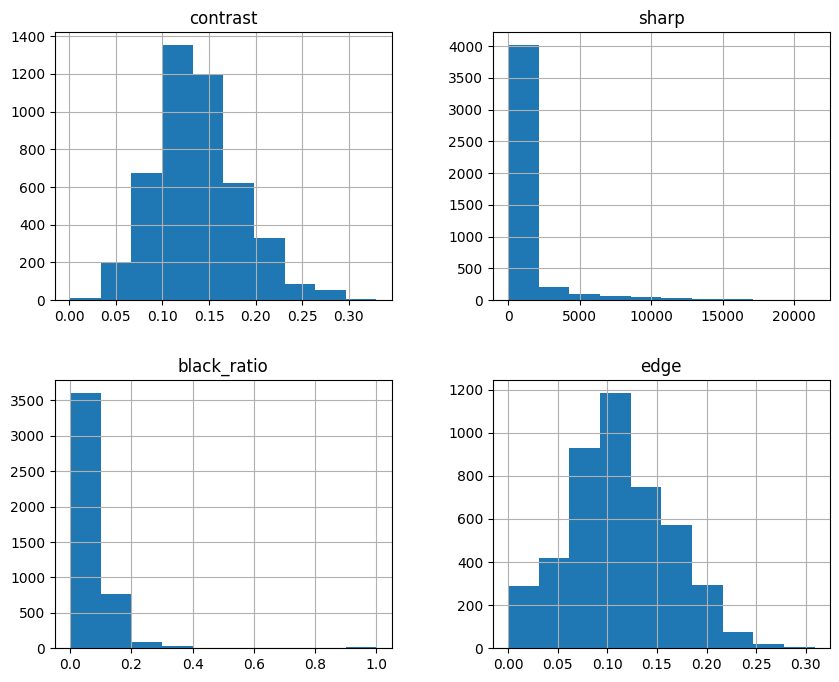

In [ ]:
df.hist(figsize=(10,8))
plt.show()

In [ ]:
X = df[['contrast', 'sharp', 'black_ratio', 'edge']]
y = df['kelas']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5744211686879823
                    precision    recall  f1-score   support

               QTY       0.73      0.67      0.70       184
      harga_satuan       0.37      0.31      0.34       159
       nama_produk       0.83      0.86      0.84       198
           tanggal       0.60      0.49      0.54        81
total_harga_barang       0.43      0.59      0.50       208
   total_transaksi       0.33      0.21      0.26        77

          accuracy                           0.57       907
         macro avg       0.55      0.52      0.53       907
      weighted avg       0.57      0.57      0.57       907



In [ ]:
df['prediksi'] = model.predict(X)

output_path = "/content/drive/MyDrive/capstone/praprosesing/hasil_prediksi.csv"
df.to_csv(output_path, index=False)

print("Disimpan di:", output_path)

Disimpan di: /content/drive/MyDrive/capstone/praprosesing/hasil_prediksi.csv
